# 6CS012 - Worksheet 5
## End-to-End CNN Model for Image Classification (Amazon Fruits Dataset)
---

## Imports & Setup

In [27]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report

# Reproducibility
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## Paths — adjust if your folder structure differs

In [28]:
# ------------------------------------------------------------------ #
# CHANGE these paths to match where you extracted the dataset.
# Expected structure:
#   dataset/
#     train/
#       pupunha/  guarana/  graviola/  tucuma/  acai/  cupuacu/
#     test/
#       pupunha/  guarana/  ...
# ------------------------------------------------------------------ #

TRAIN_DIR = "/content/drive/MyDrive/AI-ML/Week-5/FruitinAmazon/train"
TEST_DIR  = "/content/drive/MyDrive/AI-ML/Week-5/FruitinAmazon/test"

IMG_HEIGHT   = 128
IMG_WIDTH    = 128
BATCH_SIZE   = 32
VAL_SPLIT    = 0.2
NUM_CLASSES  = len(os.listdir(TRAIN_DIR))  # auto-detect
CLASS_NAMES  = sorted(os.listdir(TRAIN_DIR))

print('Classes found:', CLASS_NAMES)
print('Number of classes:', NUM_CLASSES)

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


---
## Task 1 — Data Understanding and Visualization

### 1a. Visualise one random image per class (2-row grid)

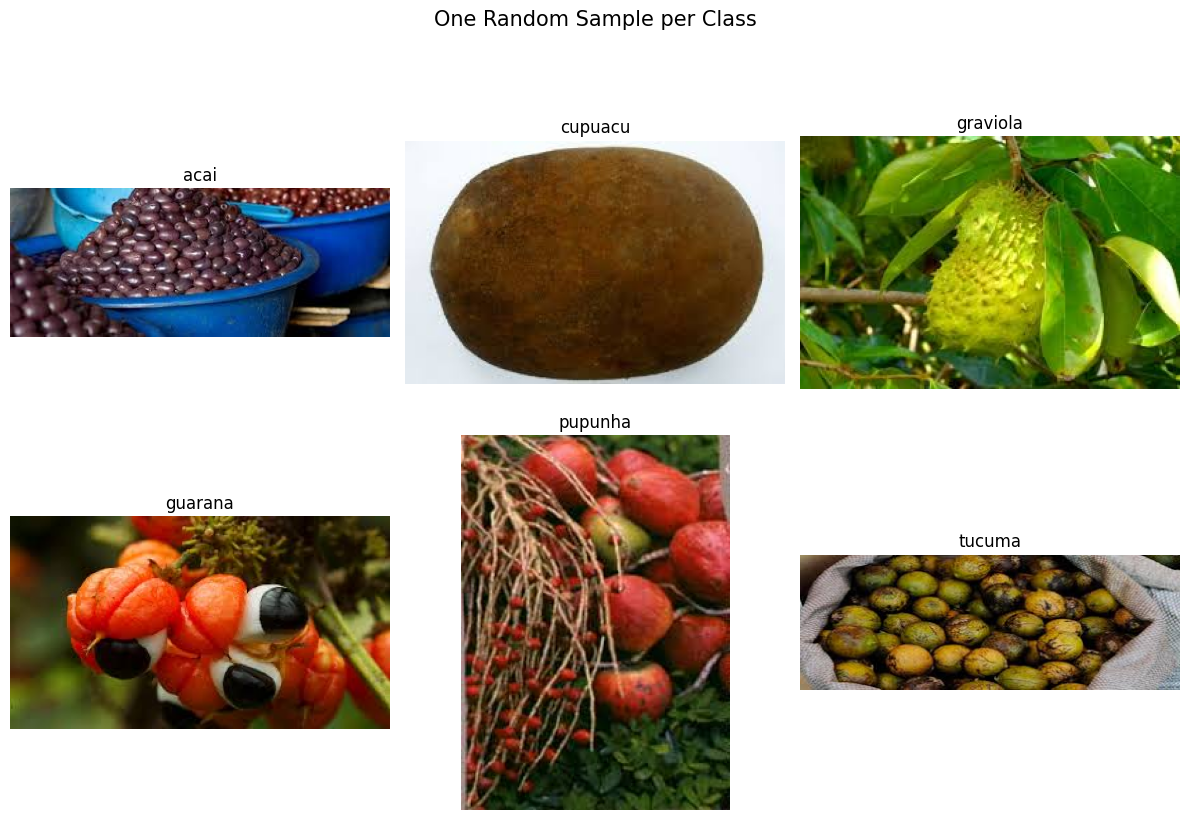

Plot saved as task1_visualization.png


In [29]:
class_dirs = sorted(
    [d for d in os.listdir(TRAIN_DIR)
     if os.path.isdir(os.path.join(TRAIN_DIR, d))]
)

sample_images = []
sample_labels = []

for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    images   = os.listdir(cls_path)
    chosen   = random.choice(images)
    sample_images.append(os.path.join(cls_path, chosen))
    sample_labels.append(cls)

n      = len(sample_images)
n_cols = (n + 1) // 2          # distribute across 2 rows
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = Image.open(img_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=12)
    axes[i].axis('off')

# Hide any unused subplot slots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('One Random Sample per Class', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('task1_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as task1_visualization.png')

**Observation:** The dataset contains 6 Amazonian fruit classes — *pupunha, guarana, graviola, tucuma, acai, cupuacu*. Images vary considerably in background, lighting, colour, and object scale, which makes this a non-trivial classification problem. Some classes (e.g. acai) are small dark berries while others (e.g. graviola) are large and uniquely shaped — giving the CNN distinctive textures and colours to learn from.

### 1b. Check for and Remove Corrupted Images

In [30]:
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(img_path)
            img.verify()          # checks file integrity without decoding
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f'Removed corrupted image: {img_path}')

if not corrupted:
    print('No corrupted images found.')
else:
    print(f'\nTotal corrupted images removed: {len(corrupted)}')

No corrupted images found.


---
## Task 2 — Loading and Preprocessing Image Data

In [31]:
# Normalisation layer (pixel values 0-255  →  0-1)
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ---- Training dataset ----
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED
)
CLASS_NAMES = train_ds_raw.class_names # Capture class names here
train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

# ---- Validation dataset ----
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED
)
val_ds = val_ds_raw.map(lambda x, y: (rescale(x), y))

# ---- Test dataset (no split, no shuffle) ----
test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)
test_ds = test_ds_raw.map(lambda x, y: (rescale(x), y))

print('Class names (train):', CLASS_NAMES)
print('Training batches  :', len(train_ds))
print('Validation batches:', len(val_ds))
print('Test batches      :', len(test_ds))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names (train): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Training batches  : 3
Validation batches: 1
Test batches      : 1


---
## Task 3 — Build the CNN Model

In [32]:
NUM_CLASSES = len(CLASS_NAMES)

model = keras.Sequential([
    # ── Convolutional Block 1 ──────────────────────────────────────
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        strides=1,
        activation='relu',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ── Convolutional Block 2 ──────────────────────────────────────
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        strides=1,
        activation='relu'
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ── Fully Connected Network ────────────────────────────────────
    layers.Flatten(),
    layers.Dense(64,  activation='relu'),   # Hidden Layer 1
    layers.Dense(128, activation='relu'),   # Hidden Layer 2
    layers.Dense(NUM_CLASSES, activation='softmax')  # Output
], name='CNN_Amazon_Fruits')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Amazon_Fruits"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4 — Compile the Model

In [33]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Model compiled successfully.')

Model compiled successfully.


---
## Task 4 (continued) — Train the Model

In [35]:
# Callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,           # stop if no improvement for 20 epochs
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=250,
    batch_size=16,         # as specified in worksheet
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.1892 - loss: 2.1477
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 646ms/step - accuracy: 0.2083 - loss: 2.2911 - val_accuracy: 0.1667 - val_loss: 1.7599
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.2031 - loss: 1.8197
Epoch 2: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 840ms/step - accuracy: 0.2500 - loss: 1.7945 - val_accuracy: 0.1111 - val_loss: 1.9740
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.3241 - loss: 1.6390
Epoch 3: val_accuracy improved from 0.16667 to 0.72222, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 501ms/step - accuracy: 0.3472 - loss: 1.6057 - val_accuracy: 0.7222 - val_loss: 1.3233
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.4288 - loss: 1.4752
Epoch 4: val_accuracy improved from 0.72222 to 0.83333, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 558ms/step - accuracy: 0.4583 - loss: 1.4590 - val_accuracy: 0.8333 - val_loss: 1.0581
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.4253 - loss: 1.3221
Epoch 5: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 510ms/step - accuracy: 0.4167 - loss: 1.2948 - val_accuracy: 0.7778 - val_loss: 0.9345
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.5758 - loss: 1.1300
Epoch 6: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 518ms/step - accuracy: 0.5556 - loss: 1.1847 - val_accuracy: 0.6667 - val_loss: 0.8916
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.6852 - loss: 0.9221
Epoch 7: val_accuracy improved from 0.83333 to 0.94444, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 614ms/step - accuracy: 0.6806 - loss: 0.9392 - val_accuracy: 0.9444 - val_loss: 0.4488
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.7483 - loss: 0.8449
Epoch 8: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 736ms/step - accuracy: 0.7917 - loss: 0.7869 - val_accuracy: 0.7222 - val_loss: 0.7821
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.8657 - loss: 0.5805
Epoch 9: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 592ms/step - accuracy: 0.8472 - loss: 0.5891 - val_accuracy: 0.9444 - val_loss: 0.3163
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9097 - loss: 0.4639
Epoch 10: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 470ms/step - accuracy: 0.9167 - loss: 0.4419 - val_accuracy: 0.6667 - val_loss: 0.6020
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.8993 - loss: 0.

### Training & Validation Curves

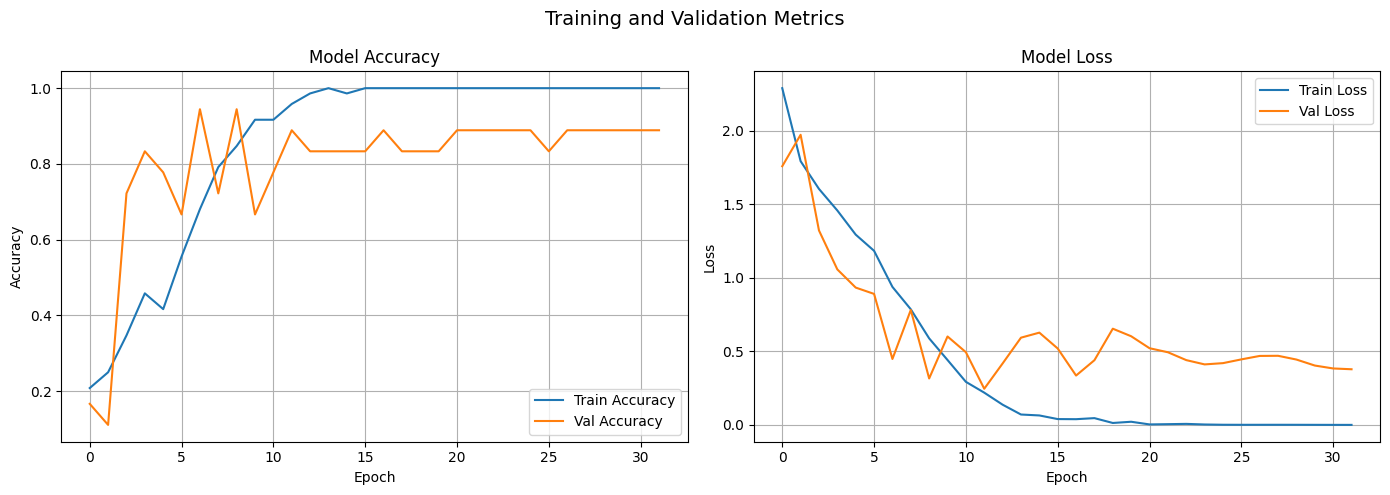

Saved: training_curves.png


In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Training and Validation Metrics', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

---
## Task 5 — Evaluate the Model

In [37]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f'\nTest Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.6000 - loss: 1.0214

Test Loss    : 1.0214
Test Accuracy: 0.6000 (60.00%)


---
## Task 6 — Save and Load the Model

In [38]:
# Save
model.save('cnn_amazon_fruits.h5')
print('Model saved as cnn_amazon_fruits.h5')

# Load
loaded_model = keras.models.load_model('cnn_amazon_fruits.h5')
print('Model loaded successfully.')

# Re-evaluate with the loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f'\nLoaded Model — Test Loss    : {loaded_loss:.4f}')
print(f'Loaded Model — Test Accuracy: {loaded_acc:.4f} ({loaded_acc*100:.2f}%)')

Model saved as cnn_amazon_fruits.h5
Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step - accuracy: 0.6000 - loss: 1.0214

Loaded Model — Test Loss    : 1.0214
Loaded Model — Test Accuracy: 0.6000 (60.00%)


---
## Task 7 — Predictions and Classification Report

In [39]:
# ── Collect all true labels and predictions from the test set ──────
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true  = np.array(y_true)
y_pred  = np.argmax(np.array(y_pred_probs), axis=1)

# ── Classification Report ──────────────────────────────────────────
class_names = CLASS_NAMES
report = classification_report(y_true, y_pred, target_names=class_names)
print('Classification Report:\n')
print(report)

Classification Report:

              precision    recall  f1-score   support

        acai       0.57      0.80      0.67         5
     cupuacu       0.38      0.60      0.46         5
    graviola       0.80      0.80      0.80         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.62      1.00      0.77         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.60        30
   macro avg       0.56      0.60      0.54        30
weighted avg       0.56      0.60      0.54        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Sample Predictions (first 10 test images)

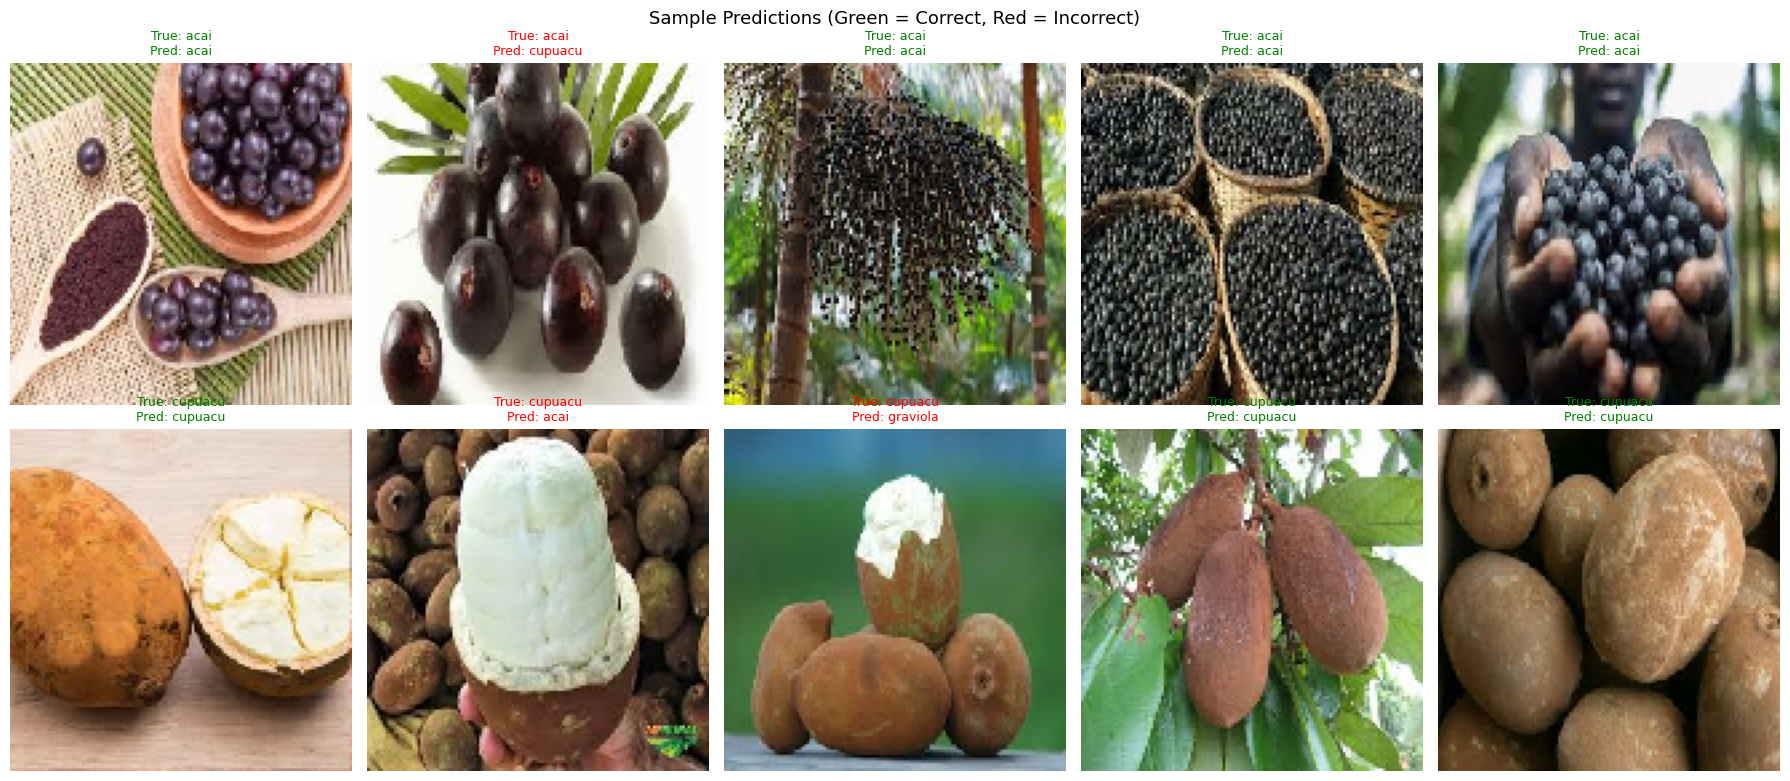

Saved: sample_predictions.png


In [17]:
# Grab first batch from test_ds for display
sample_batch_images, sample_batch_labels = next(iter(test_ds))
sample_preds = np.argmax(loaded_model.predict(sample_batch_images, verbose=0), axis=1)

n_show = min(10, len(sample_batch_images))
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i in range(n_show):
    img   = sample_batch_images[i].numpy()
    true  = class_names[sample_batch_labels[i].numpy()]
    pred  = class_names[sample_preds[i]]
    color = 'green' if true == pred else 'red'
    axes[i].imshow(img)
    axes[i].set_title(f'True: {true}\nPred: {pred}', color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green = Correct, Red = Incorrect)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_predictions.png')